In [2]:
import sys
import os
os.chdir("/home/felixpersson/MasterThesisProject")
print(os.getcwd())

/home/felixpersson/MasterThesisProject


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import meshio

from models.moderator.mesh_conduction_model import RectangularTestDiscretisedMesh
from models.moderator.triangle_mesh import UnstructuredMesh

%config InlineBackend.figure_format = "retina"

In [48]:
rect_mesh = meshio.read("models/moderator/rect_mesh.msh")

points = rect_mesh.points[:, :2]                
triangles = rect_mesh.cells_dict["triangle"]     
rect_mesh = UnstructuredMesh(points, triangles)

print(f"Number of elements: {triangles.shape}, Number of points: {points.shape}")

cell_k = np.ones(triangles.shape[0])
cell_T = np.ones(triangles.shape[0])
l_pitch = 0.0286
r_HP = 0.008
r_f = 0.0065
theta_mod = (np.pi / 6)
l_f = 1.8

rect_data = {
    "cell_k": 20 * np.ones(triangles.shape[0]),
    "cell_T": np.ones(triangles.shape[0]),

    "Q_in": 1e3,

    "HP_centers":       [[0., 0.], [np.tan(theta_mod) * 2. * l_pitch, 2. * l_pitch]],
    "fuel_pin_centers": [[0, l_pitch * 3./2.], [0, l_pitch * 5./2.], [np.tan(theta_mod) * 2 * l_pitch, l_pitch * 7./2.]],
    "HP_radius": r_HP,
    "fuel_pin_radius": r_f,

    "T_HP": 850,
    "T_FP": 885,

    "HP_BC": "vonNeumann",   #"Dirichlet"
    "FP_BC": "vonNeumann"   #"vonNeumann"
}

#mod_disc_mesh = ModeratorDiscretisedMesh(mesh=mod_mesh, data=mod_data)
rect_disc_mesh = RectangularTestDiscretisedMesh(mesh=rect_mesh, data=rect_data)

T = rect_disc_mesh.solve(iterations=6)
T -= np.min(T)


Number of elements: (18482, 3), Number of points: (9482, 2)
[69.45354751 89.60478086  0.58816978 ... 32.76587658 78.87944045
 81.57836283]
[69.11673612 89.61845785  0.49911843 ... 32.79588196 78.98535524
 81.68470739]
[69.13088237 89.64597155  0.49916278 ... 32.80322238 79.00648456
 81.71041973]
[69.13043822 89.64582492  0.49892105 ... 32.80350037 79.00669812
 81.71086074]
[69.13047814 89.64590572  0.49892165 ... 32.8034896  79.00674858
 81.7109238 ]
[69.13047523 89.64590235  0.49892123 ... 32.80349333 79.00674779
 81.71092415]


In [65]:
import matplotlib.tri as mtri

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "mathtext.fontset": "cm",
    "font.size": 30,
    "text.usetex": True,
    "axes.linewidth": 1.2,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,
    "legend.frameon": True,
    "legend.framealpha": 0.95,
    "legend.edgecolor": "0.7",
})

colors = {
    "blue": "#0077BB",
    "cyan": "#33BBEE",
    "teal": "#009988",
    "orange": "#EE7733",
    "red": "#CC3311",
    "magenta": "#EE3377",
    "grey": "#BBBBBB",
}


from matplotlib.ticker import AutoMinorLocator


def _apply_thesis_grid(ax):
    ax.minorticks_on()

    ax.grid(
        which="major",
        alpha=0.35,
        linewidth=0.8,
        zorder=0,
    )

    ax.grid(
        which="minor",
        alpha=0.18,
        linewidth=0.45,
        zorder=0,
    )

    ax.tick_params(
        which="both",
        direction="in",
        top=True,
        right=True,
    )

    ax.tick_params(which="major", length=6, width=1.0)
    ax.tick_params(which="minor", length=3, width=0.8)


def plot_rectangular_test(
    mod_mesh,
    cell_T,
    Q_in,
    k,
    height,
    lenght,
    save_path=None,
    show=True,
):
    """
    Thesis-style validation plot for the rectangular 1D conduction test.

    The analytical solution is shifted using the least-squares optimal
    constant offset, since a pure Neumann problem only determines the
    solution up to an arbitrary additive constant.
    """

    mesh = mod_mesh.mesh
    cell_T = np.asarray(cell_T, dtype=float)

    centers = np.array([
        mesh.get_center_point(i)
        for i in range(mesh.triangles.shape[0])
    ])

    x = centers[:, 0]

    sort_idx = np.argsort(x)
    x_sorted = x[sort_idx]
    T_sorted = cell_T[sort_idx]

    x_min = np.min(x_sorted)
    x_max = np.max(x_sorted)

    # Surface heat flux. Positive heat flow is assumed from left to right.
    q_surface = Q_in / height

    # ------------------------------------------------------------------
    # Analytical solution
    # ------------------------------------------------------------------
    # For 1D steady conduction:
    #
    #     dT/dx = -q/k
    #
    # Hence:
    #
    #     T_a(x) = -(q/k)(x - x_min) + C
    #
    # For a pure Neumann problem, C is arbitrary. Choose C so that the
    # analytical solution is the least-squares best fit to the numerical one.
    T_analytical_raw = -(q_surface / k) * (x_sorted - x_min)

    C_opt = np.mean(T_sorted - T_analytical_raw)

    T_analytical_shifted = T_analytical_raw + C_opt

    error = T_sorted - T_analytical_shifted
    rmse = np.sqrt(np.mean(error**2))
    max_abs_error = np.max(np.abs(error))

    x_line = np.linspace(x_min, x_max, 500)
    T_line_raw = -(q_surface / k) * (x_line - x_min)
    T_line = T_line_raw + C_opt

    fig, (ax, ax_res) = plt.subplots(
        2,
        1,
        figsize=(13, 10),
        sharex=True,
        constrained_layout=True,
        gridspec_kw={"height_ratios": [3.2, 1.0]},
    )

    fig.set_constrained_layout_pads(
        w_pad=0.08,
        h_pad=0.08,
        hspace=0.06,
    )

    # ------------------------------------------------------------------
    # Main validation plot
    # ------------------------------------------------------------------
    _apply_thesis_grid(ax)

    ax.scatter(
        x_sorted,
        T_sorted,
        s=18,
        marker="o",
        facecolors=colors["blue"],
        edgecolors="none",
        alpha=0.75,
        label=r"Numerical solution",
        zorder=3,
        rasterized=True,
    )

    ax.plot(
        x_line,
        T_line,
        color=colors["orange"],
        linewidth=3.0,
        ls="--",
        label=r"Analytical solution",
        zorder=4,
    )

    ax.set_ylabel(r"Temperature difference  $\Delta T$ [K]", labelpad=12)

    legend = ax.legend(
        loc="upper right",
        bbox_to_anchor=(0.99, 0.99),
        fontsize=24,
        handlelength=2.2,
        borderpad=0.45,
        labelspacing=0.55,
    )
    legend.set_zorder(10)

    error_text = (
        rf"$\mathrm{{RMSE}} = {rmse:.2e}\,\mathrm{{K}}$"
        "\n"
        rf"$\max(|e|) = {max_abs_error:.2e}\,\mathrm{{K}}$"
    )

    ax.text(
        0.967,
        0.75,
        error_text,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=22,
        bbox=dict(
            facecolor="white",
            edgecolor=colors["grey"],
            boxstyle="round,pad=0.35",
            alpha=0.95,
        ),
        zorder=9,
    )

    # ------------------------------------------------------------------
    # Residual plot
    # ------------------------------------------------------------------
    _apply_thesis_grid(ax_res)

    ax_res.axhline(
        0.0,
        color="black",
        linewidth=1.1,
        alpha=0.65,
        zorder=1,
    )

    ax_res.scatter(
        x_sorted,
        error,
        s=16,
        marker="o",
        facecolors=colors["red"],
        edgecolors="black",
        linewidths=1.1,
        alpha=0.95,
        zorder=3,
    )

    ax_res.set_xlabel(r"Position $x$ [m]", labelpad=10)
    ax_res.set_ylabel(r"error $e$ [K]", labelpad=12)

    # ------------------------------------------------------------------
    # Slightly zoom out both x and y limits
    # ------------------------------------------------------------------
    x_pad = 0.025 * (x_max - x_min)
    ax.set_xlim(x_min - x_pad, x_max + x_pad)

    T_all = np.concatenate([T_sorted, T_line])
    T_min = np.min(T_all)
    T_max = np.max(T_all)
    T_pad = 0.08 * (T_max - T_min)

    ax.set_ylim(T_min - T_pad, T_max + T_pad)

    e_abs = np.max(np.abs(error))
    e_pad = 0.25 * e_abs if e_abs > 0 else 1.0

    ax_res.set_ylim(
        -e_abs - e_pad,
         e_abs + e_pad,
    )

    fig.align_ylabels([ax, ax_res])

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    if show:
        plt.show()

    return rmse


def plot_mesh_with_temp_profile(
    points,
    triangles,
    T,
    save_path=None,
    show=True,
    cmap="inferno",
    show_edges=True,
):
    """
    Thesis-style 2D triangular mesh temperature plot.

    Parameters
    ----------
    points : np.ndarray
        Mesh points, shape (n_points, 2) or (n_points, 3).
    triangles : np.ndarray
        Triangle connectivity, shape (n_triangles, 3).
    T : np.ndarray
        Cell-centred temperature values, shape (n_triangles,).
    save_path : str | None
        Optional path for saving the figure, e.g. "mesh_temperature.pdf".
    show : bool
        If True, show the figure.
    cmap : str
        Matplotlib colormap.
    show_edges : bool
        If True, draw triangle edges.

    Returns
    -------
    fig, ax
        Matplotlib figure and axis.
    """

    points = np.asarray(points, dtype=float)
    triangles = np.asarray(triangles, dtype=int)
    T = np.asarray(T, dtype=float)

    if points.shape[1] > 2:
        points = points[:, :2]

    if T.shape[0] != triangles.shape[0]:
        raise ValueError(
            "Expected cell-centred temperature data with "
            f"shape ({triangles.shape[0]},), got {T.shape}."
        )

    triangulation = mtri.Triangulation(
        points[:, 0],
        points[:, 1],
        triangles,
    )

    fig, ax = plt.subplots(
        figsize=(10, 9),
        constrained_layout=True,
    )

    edge_color = "0.25" if show_edges else "none"
    edge_width = 0.25 if show_edges else 0.0

    temperature_plot = ax.tripcolor(
        triangulation,
        facecolors=T,
        shading="flat",
        cmap=cmap,
        edgecolors=edge_color,
        linewidth=edge_width,
        antialiased=True,
        rasterized=True,
    )

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(r"$x$ [m]")
    ax.set_ylabel(r"$y$ [m]")

    ax.tick_params(
        which="both",
        top=True,
        right=True,
    )

    cbar = fig.colorbar(
        temperature_plot,
        ax=ax,
        pad=0.025,
        shrink=0.9,
    )

    cbar.set_label(r"Temperature rise $\Delta T$ [K]")
    cbar.ax.tick_params(labelsize=24)

    # Add a small margin so the mesh does not touch the axis frame.
    x_min, x_max = np.min(points[:, 0]), np.max(points[:, 0])
    y_min, y_max = np.min(points[:, 1]), np.max(points[:, 1])

    dx = x_max - x_min
    dy = y_max - y_min

    ax.set_xlim(x_min - 0.02 * dx, x_max + 0.02 * dx)
    ax.set_ylim(y_min - 0.02 * dy, y_max + 0.02 * dy)

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    if show:
        plt.show()

    return fig, ax

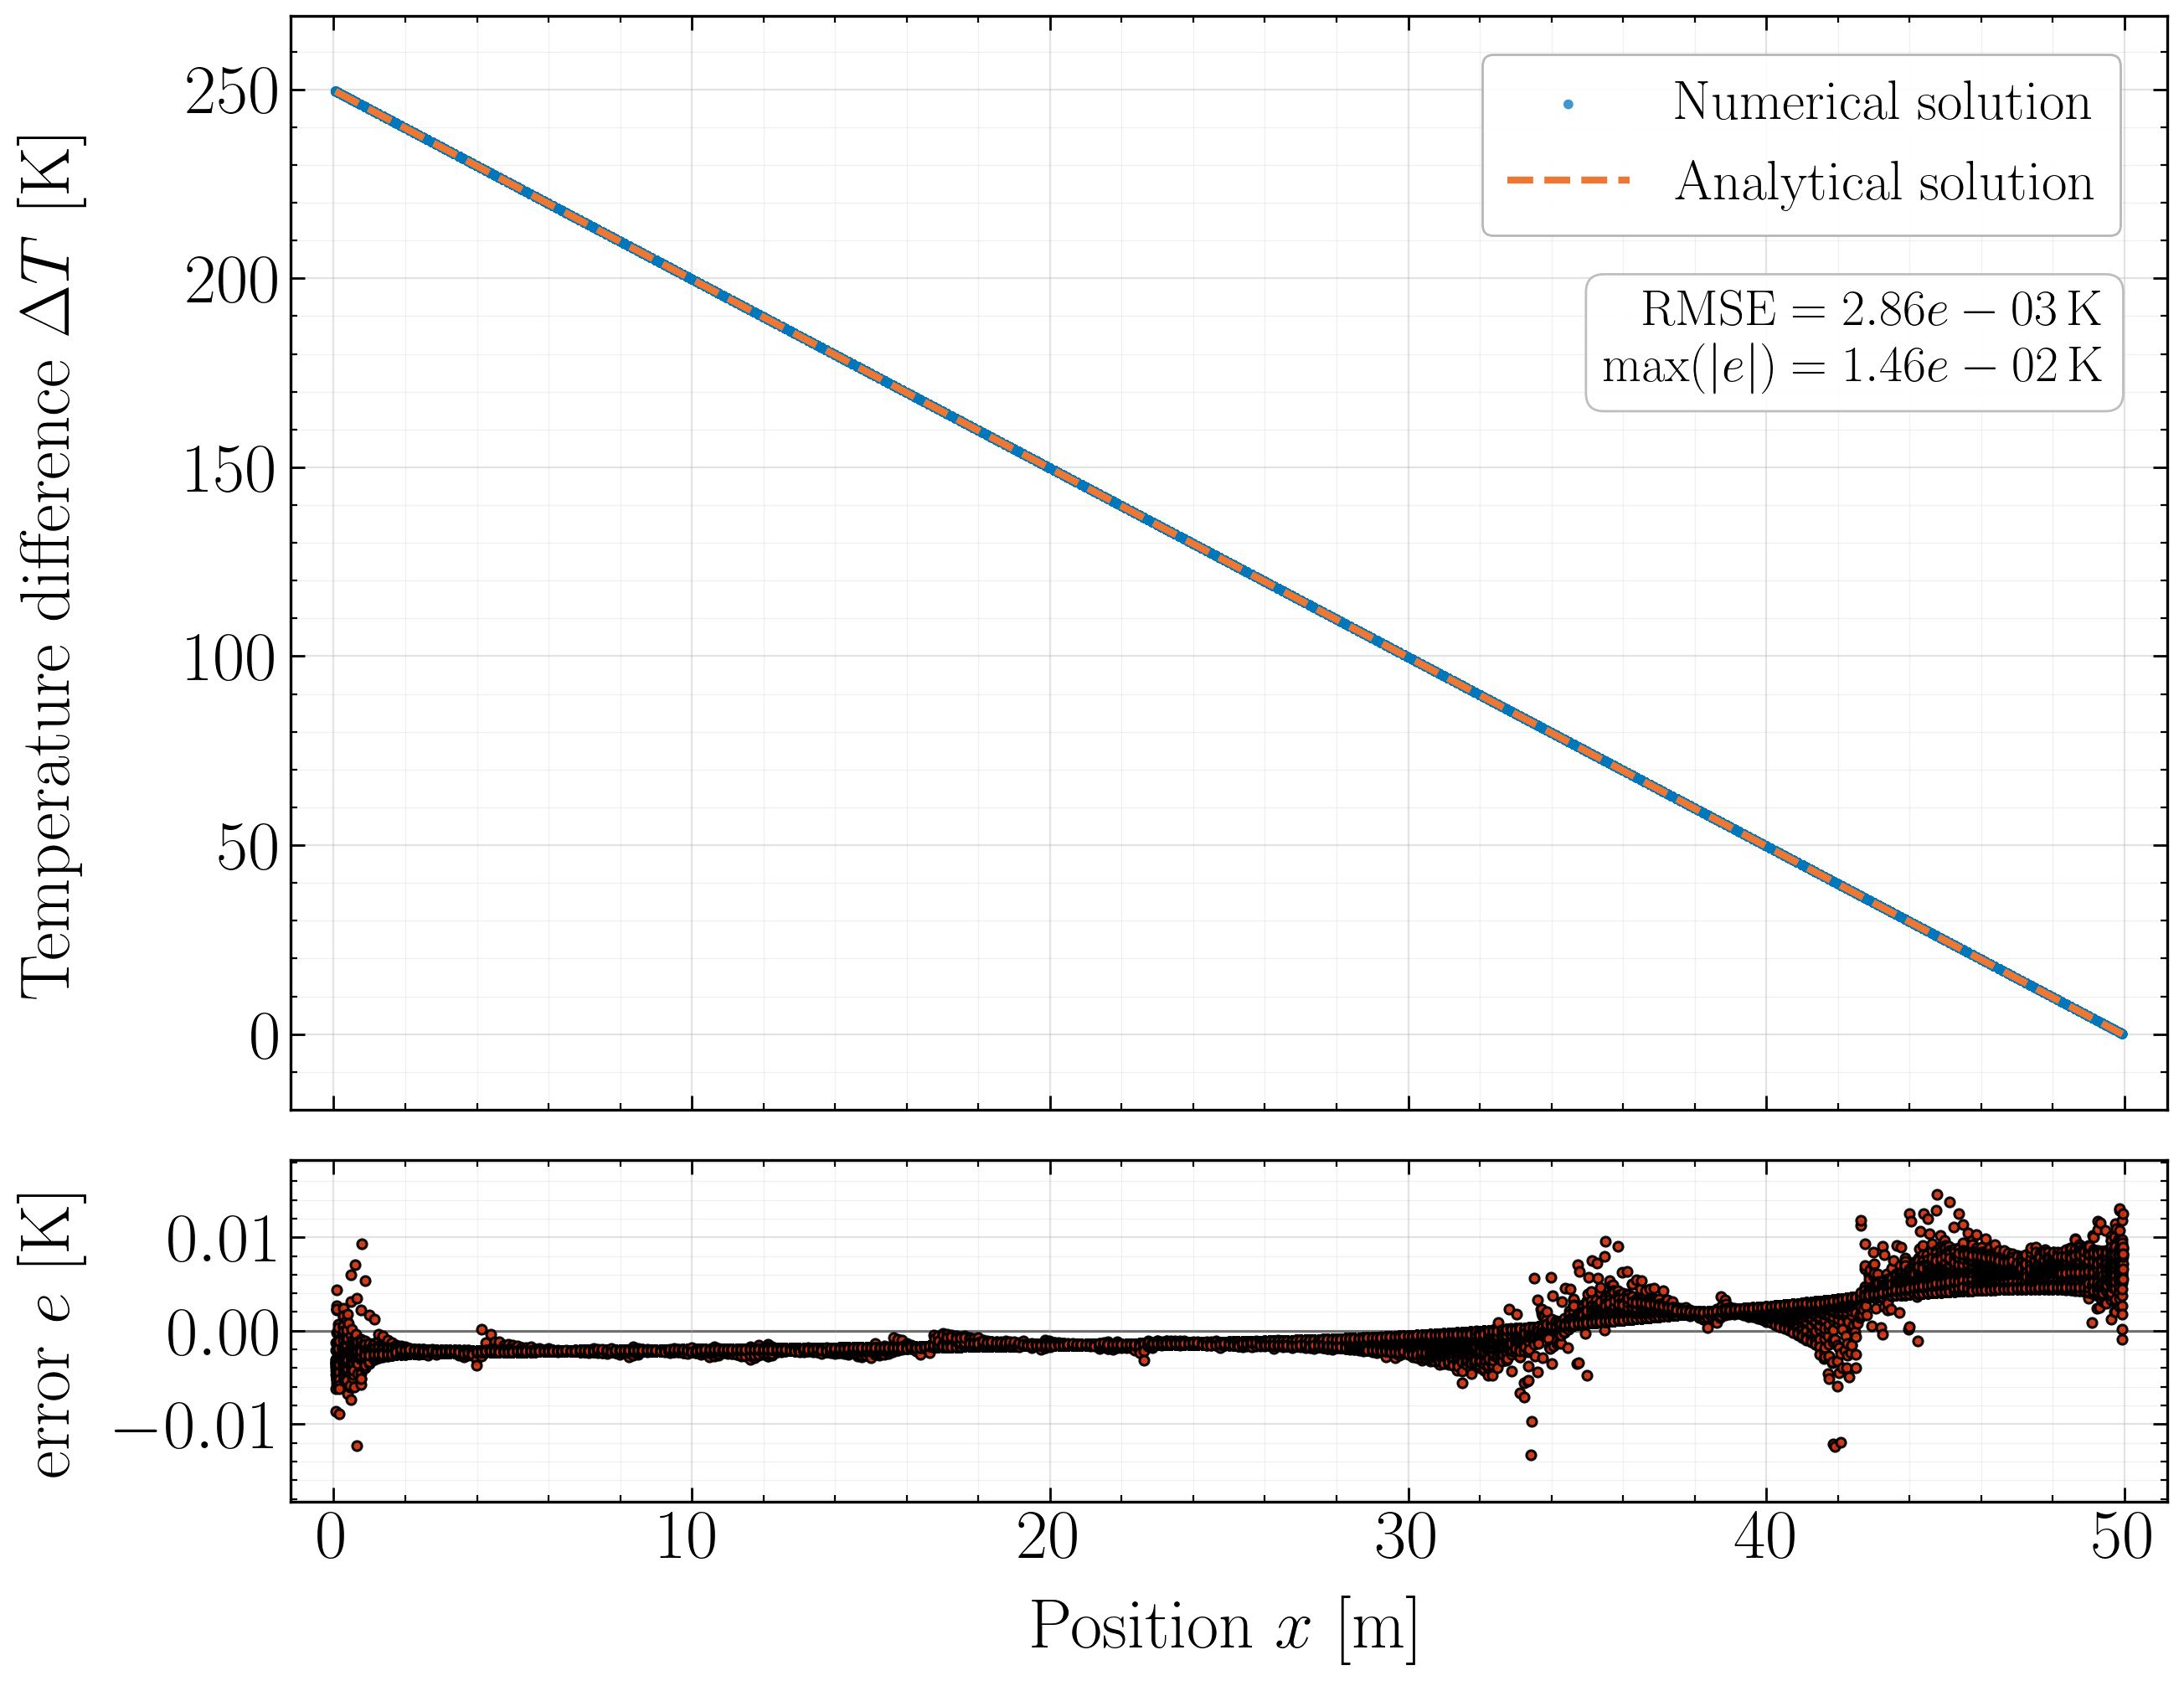

np.float64(0.0028633081281038177)

In [69]:
plot_rectangular_test(
    rect_disc_mesh,
    T,
    rect_data["Q_in"],
    rect_data["cell_k"][0],
    10.,
    50.,
    save_path="rectangular_validation.pdf",)



In [74]:
from matplotlib.ticker import MaxNLocator

def plot_mesh_with_temp_profile(
    points,
    triangles,
    T,
    save_path=None,
    show=True,
    cmap="inferno",
    show_edges=True,
):
    """
    Thesis-style 2D triangular mesh temperature plot with a horizontal
    colorbar aligned below the mesh.
    """

    points = np.asarray(points, dtype=float)
    triangles = np.asarray(triangles, dtype=int)
    T = np.asarray(T, dtype=float)

    if points.shape[1] > 2:
        points = points[:, :2]

    if T.shape[0] != triangles.shape[0]:
        raise ValueError(
            "Expected cell-centred temperature data with "
            f"shape ({triangles.shape[0]},), got {T.shape}."
        )

    triangulation = mtri.Triangulation(
        points[:, 0],
        points[:, 1],
        triangles,
    )

    # ------------------------------------------------------------------
    # Domain limits
    # ------------------------------------------------------------------
    x_min, x_max = np.min(points[:, 0]), np.max(points[:, 0])
    y_min, y_max = np.min(points[:, 1]), np.max(points[:, 1])

    dx = x_max - x_min
    dy = y_max - y_min

    margin = 0.0004
    x_pad = margin * dx
    y_pad = margin * dy

    aspect = dx / dy if dy > 0 else 1.0

    fig_width = 11.0
    fig_height = max(4.8, min(7.2, fig_width / aspect + 1.0))

    # Use manual layout instead of constrained_layout to avoid awkward margins.
    fig = plt.figure(figsize=(fig_width, fig_height), constrained_layout=False)

    gs = fig.add_gridspec(
        nrows=2,
        ncols=1,
        height_ratios=[1.0, 0.065],
        hspace=0.78,
        left=0.035,
        right=0.985,
        bottom=0.18,
        top=0.98,
    )

    ax = fig.add_subplot(gs[0])
    cax = fig.add_subplot(gs[1])

    # ------------------------------------------------------------------
    # Mesh temperature field
    # ------------------------------------------------------------------
    edge_color = "0.20" if show_edges else "none"
    edge_width = 0.16 if show_edges else 0.0

    temperature_plot = ax.tripcolor(
        triangulation,
        facecolors=T,
        shading="flat",
        cmap=cmap,
        edgecolors=edge_color,
        linewidth=edge_width,
        antialiased=True,
        rasterized=True,
    )

    ax.set_aspect("equal", adjustable="box")

    # Anchor the equal-aspect plot to the left to avoid unused space there.
    ax.set_anchor("W")

    ax.set_xlim(x_min - x_pad, x_max + x_pad)
    ax.set_ylim(y_min - y_pad, y_max + y_pad)

    ax.set_xlabel(r"$x$ [m]", labelpad=8)
    ax.set_ylabel(r"$y$ [m]", labelpad=4)

    # Only show y ticks at 0.0 and 10.0
    ax.set_yticks([0.0, 10.0])
    ax.set_yticklabels([r"$0.0$", r"$10.0$"])

    ax.xaxis.set_major_locator(MaxNLocator(nbins=6))

    # Cleaner axis frame
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_linewidth(1.0)
    ax.spines["bottom"].set_linewidth(1.0)
    ax.spines["left"].set_color("0.25")
    ax.spines["bottom"].set_color("0.25")

    # Ticks pointing outward instead of inward.
    ax.tick_params(
        which="both",
        direction="out",
        top=False,
        right=False,
        length=5,
        width=1.0,
        pad=6,
    )

    # ------------------------------------------------------------------
    # Horizontal colorbar below the mesh
    # ------------------------------------------------------------------
    cbar = fig.colorbar(
        temperature_plot,
        cax=cax,
        orientation="horizontal",
    )

    cbar.set_label(
        r"Temperature difference $\Delta T$ [K]",
        labelpad=8,
    )

    cbar.ax.tick_params(
        labelsize=24,
        direction="out",
        length=5,
        width=1.0,
        pad=6,
    )

    cbar.ax.xaxis.set_major_locator(MaxNLocator(nbins=6))

    # Warm to cold, left to right.
    cbar.ax.invert_xaxis()

    cbar.outline.set_linewidth(0.9)
    cbar.outline.set_edgecolor("0.35")

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    if show:
        plt.show()

    return fig, ax

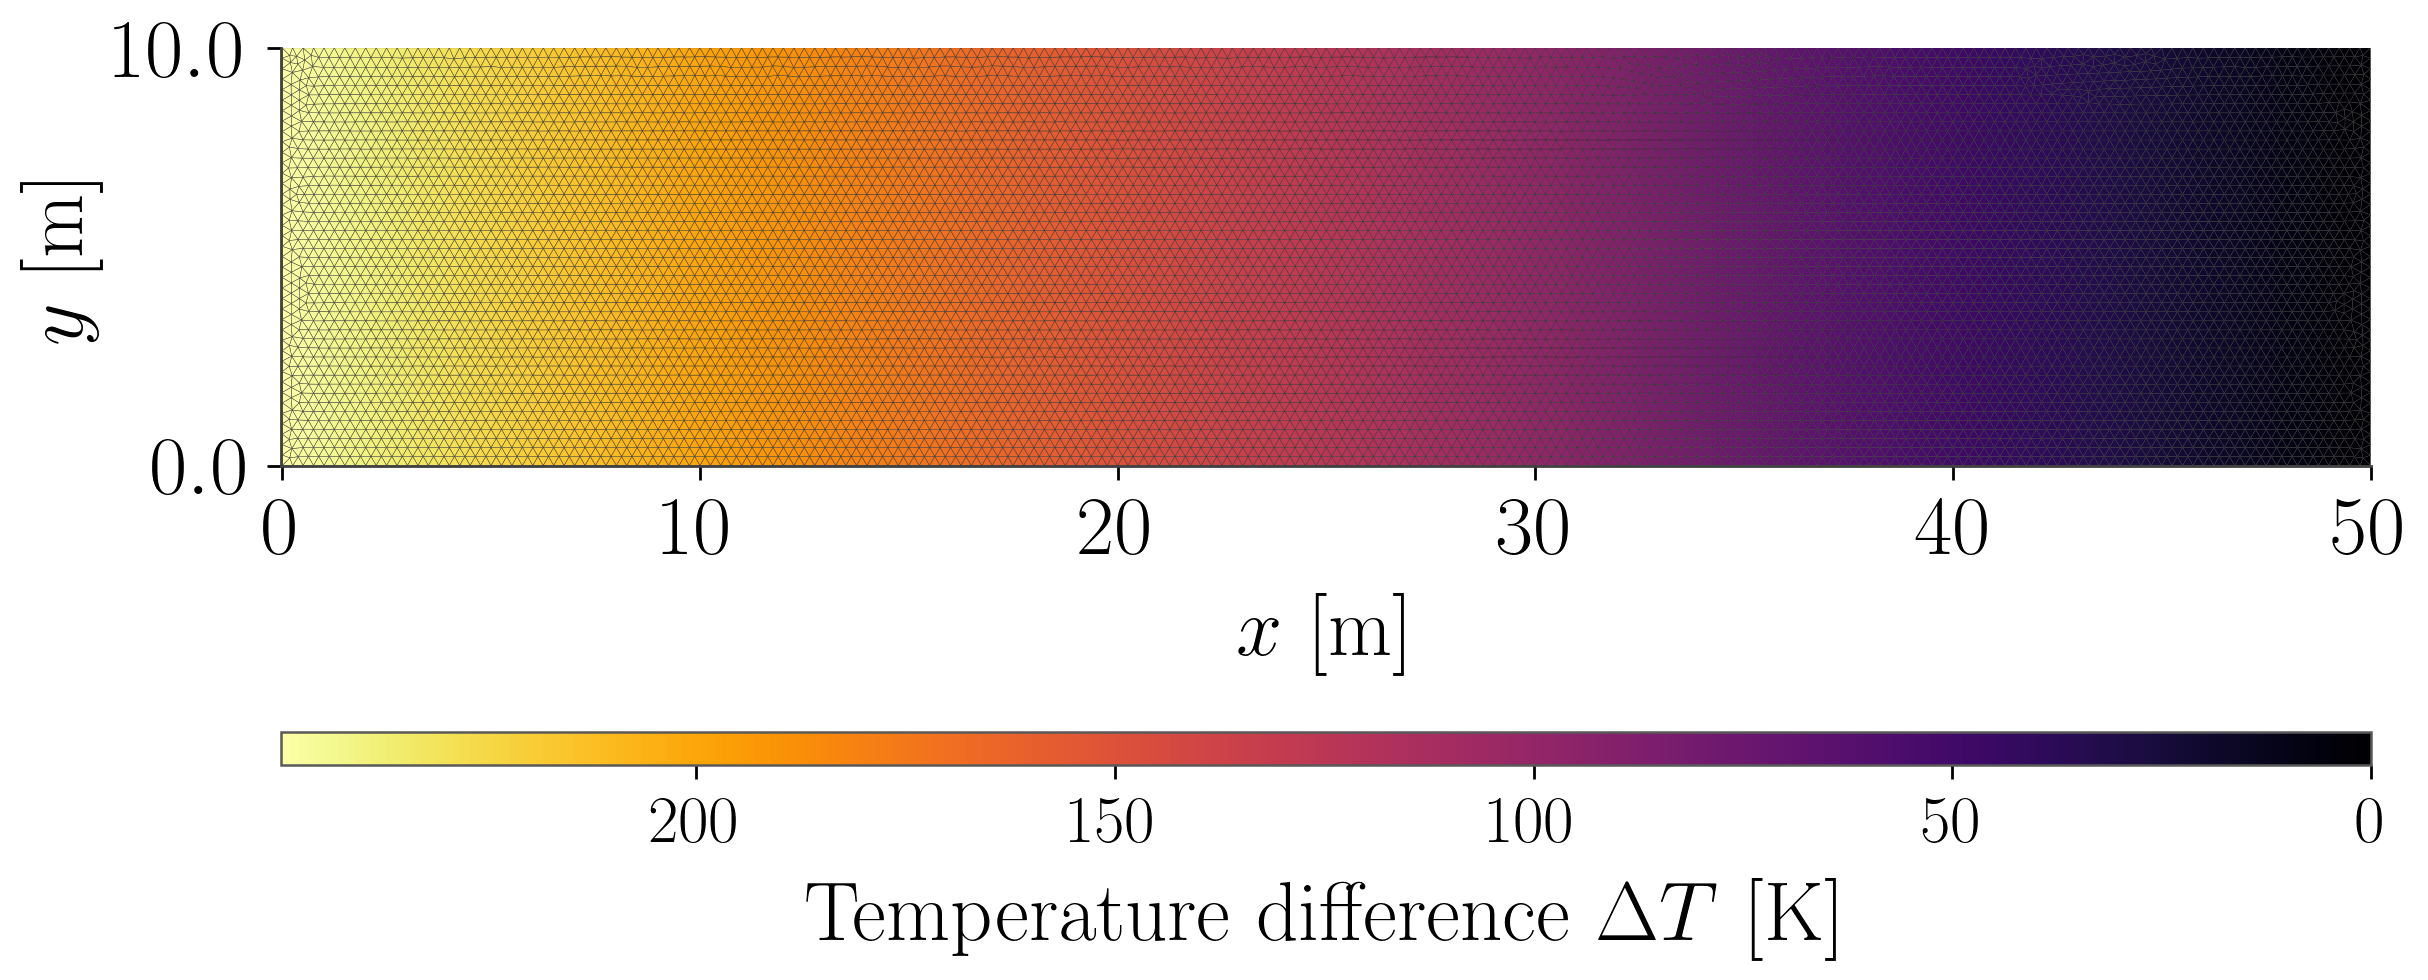

(<Figure size 1100x480 with 2 Axes>,
 <Axes: xlabel='$x$ [m]', ylabel='$y$ [m]'>)

In [75]:
plot_mesh_with_temp_profile(
    rect_disc_mesh.mesh.points,
    rect_disc_mesh.mesh.triangles,
    T,
    save_path="rectangular_temperature_field.pdf",)
